Всего действий: 32
Дискретизация:
  lambda_p: [0, 10, 20, 30, 40] (5 значений)
  buffer: [0, 20, 40, 60, 80] (5 значений)
  c0: [0, 100, 200] (3 значений)
Всего состояний: 600

FINITE HORIZON BELLMAN WITH CYCLIC PERIODS
Horizon: 5 days = 40 periods
Total states: 600
Total actions: 32
MC samples: 8


Solving Bellman: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:15<00:00, 197.80states/s]



BOOTSTRAP ANALYSIS
Number of bootstrap samples: 1000
Confidence level: 95.0%

Running initial simulations to build empirical distribution...



Original total cost (single run): 2590.00
Mean total cost over 500 runs: 3367.27
Std total cost: 1151.28

Performing bootstrap resampling (1000 samples)...


Bootstrap: 100%|██████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 523.30it/s]



BOOTSTRAP RESULTS

📊 TOTAL COST (over 5 days):
   Mean: 3368.62
   Std:  51.86
   95.0% CI: [3267.47, 3470.33]
   Width: 202.86

📊 DAILY COSTS:
   Day 1: mean=618.44, CI=(590.46, 650.27)
   Day 2: mean=741.90, CI=(695.02, 794.23)
   Day 3: mean=618.11, CI=(579.44, 656.42)
   Day 4: mean=730.68, CI=(686.56, 775.88)
   Day 5: mean=657.88, CI=(624.27, 694.11)

📊 PERIOD COSTS (averaged over days):
   Period 0 (meal_1): mean=73.15, CI=(67.50, 80.45)
   Period 1 (meal_1): mean=97.90, CI=(85.98, 111.30)
   Period 2 (meal_1): mean=107.42, CI=(91.48, 126.18)
   Period 3 (meal_2): mean=69.56, CI=(65.10, 75.41)
   Period 4 (meal_2): mean=63.58, CI=(59.80, 68.19)
   Period 5 (meal_2): mean=82.46, CI=(72.03, 93.44)
   Period 6 (meal_2): mean=56.38, CI=(49.89, 64.00)
   Period 7 (meal_2): mean=68.09, CI=(58.61, 79.23)


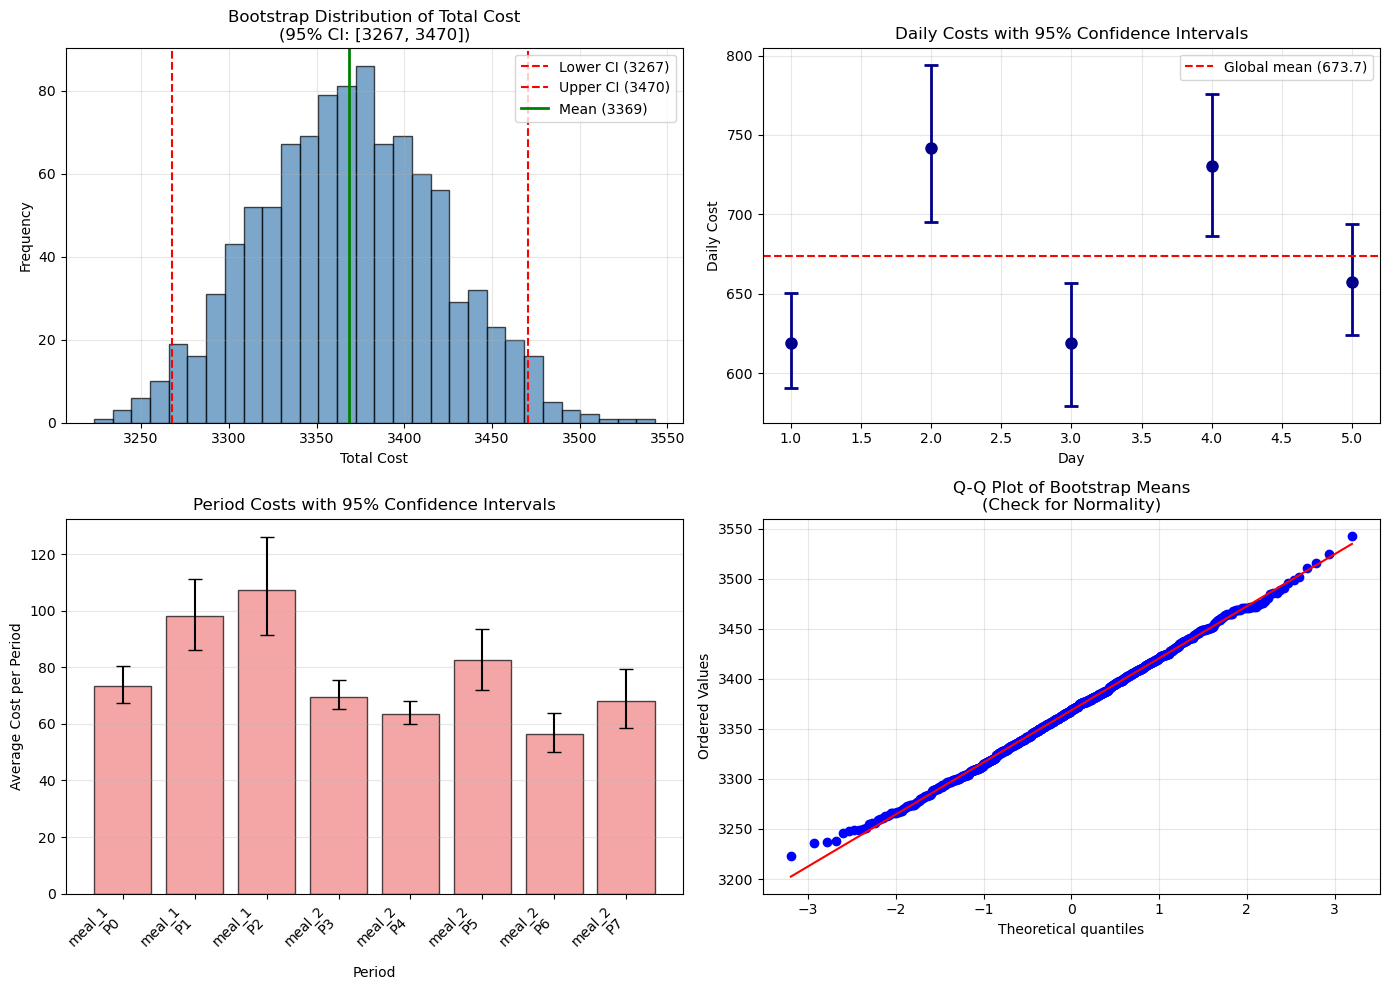


FINITE HORIZON BELLMAN WITH CYCLIC PERIODS
Horizon: 5 days = 40 periods
Total states: 600
Total actions: 32
MC samples: 8


Solving Bellman: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:13<00:00, 218.20states/s]



SIMULATION WITH DAILY RESET

DAY 1
P0 | meal_1   | γb=0.85 γp=0.85 cook= 0 | plan=102 actual=109 | unserved= 0 leftovers=13 | cost= 79.00
P1 | meal_1   | γb=0.85 γp=1.00 cook= 0 | plan=129 actual=141 | unserved= 0 leftovers= 1 | cost= 29.00
P2 | meal_1   | γb=0.95 γp=1.00 cook=10 | plan=124 actual=115 | unserved= 0 leftovers=20 | cost=110.00
P3 | meal_2   | γb=0.85 γp=0.95 cook= 0 | plan= 40 actual= 39 | unserved= 0 leftovers=21 | cost=105.00
P4 | meal_2   | γb=0.85 γp=0.90 cook= 0 | plan= 62 actual= 68 | unserved= 0 leftovers=15 | cost= 87.00
P5 | meal_2   | γb=0.85 γp=0.95 cook= 0 | plan=108 actual=125 | unserved= 2 leftovers= 0 | cost= 62.00
P6 | meal_2   | γb=1.00 γp=0.90 cook= 0 | plan= 69 actual= 67 | unserved= 0 leftovers= 2 | cost= 10.00
P7 | meal_2   | γb=1.00 γp=0.90 cook= 0 | plan=125 actual=124 | unserved= 0 leftovers= 3 | cost= 15.00

--- END OF DAY 1 ---
  Final lambda_p: 14
  Final buffer: 3 → RESET to 20
  Final c0: 190 → RESET to 200

DAY 2
P0 | meal_1   | γb=0.85 γp=

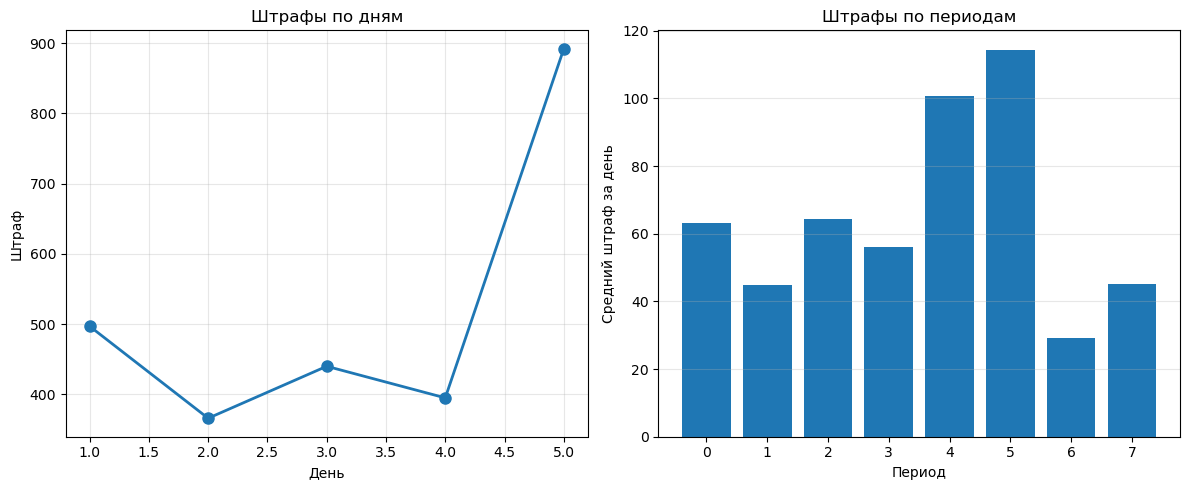

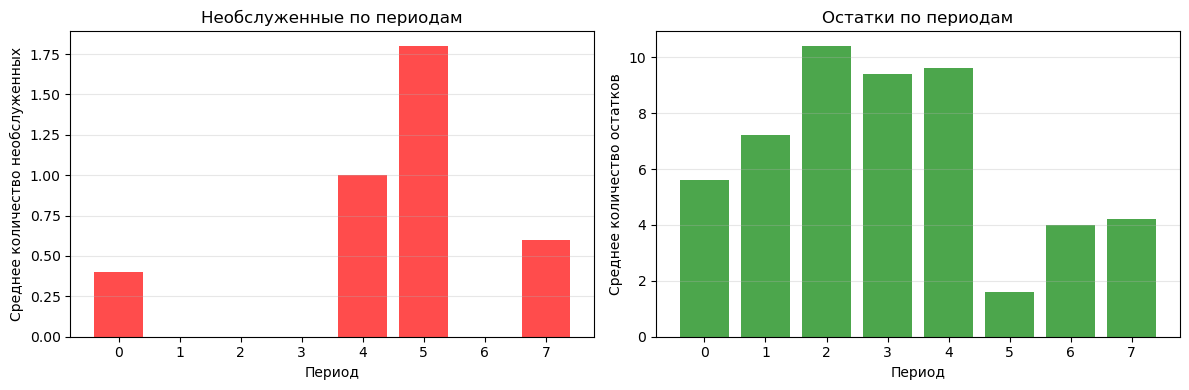

In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm import tqdm

# =====================================================
# CONFIG - УСКОРЕННЫЙ ВАРИАНТ (горизонт сохранён)
# =====================================================

INITIAL_C0 = 200
ALPHA = 0.3

LAMBDA_1 = 2.0   # использование буфера
LAMBDA_2 = 5.0   # остатки
LAMBDA_3 = 8.0   # необслуженные
LAMBDA_4 = 1.0   # доготовка

# Ускорение 1: уменьшено количество уровней перебронирования
OVERBOOKING_LEVELS = [0.85, 0.90, 0.95, 1.00]  # было 5, стало 4

# Ускорение 2: уменьшено количество вариантов доготовки
COOK_LEVELS = [0, 10]  # было 3, стало 2 (убрали 20)

BUFFER_MAX = 80
LAMBDA_MAX = 40

# Ускорение 3: уменьшено количество MC семплов
MC_SAMPLES = 8  # было 20, стало 8

DAYS_IN_HORIZON = 5  # сохранён! 5 дней

# Ускорение 4: увеличены шаги дискретизации
LAMBDA_STEP = 10     # было 5, стало 10
BUFFER_STEP = 20     # было 10, стало 20
C0_STEP = 100        # было 50, стало 100

plt.rcParams['font.family'] = 'DejaVu Sans'


# =====================================================
# DATA
# =====================================================

TIME_PERIODS = [
    {"period": 0, "meal_type": "meal_1", "groups": "1, 2 классы", "students_total": 100, "benefit_students": 100},
    {"period": 1, "meal_type": "meal_1", "groups": "3, 4, 5 классы", "students_total": 150, "benefit_students": 128},
    {"period": 2, "meal_type": "meal_1", "groups": "6, 7, 8, 9 классы", "students_total": 200, "benefit_students": 112},
    {"period": 3, "meal_type": "meal_2", "groups": "1 класс", "students_total": 50, "benefit_students": 28},
    {"period": 4, "meal_type": "meal_2", "groups": "2, 3 класс", "students_total": 100, "benefit_students": 56},
    {"period": 5, "meal_type": "meal_2", "groups": "4, 5, 6, 8 классы", "students_total": 200, "benefit_students": 112},
    {"period": 6, "meal_type": "meal_2", "groups": "7, 9 классы", "students_total": 100, "benefit_students": 56},
    {"period": 7, "meal_type": "meal_2", "groups": "школа полного дня", "students_total": 200, "benefit_students": 112},
]

T = len(TIME_PERIODS)  # 8 периодов в дне


# =====================================================
# STATE
# =====================================================

@dataclass(frozen=True)
class State:
    period: int          # текущий период (0..7)
    lambda_p: int        # оценка платящих (0..40)
    buffer: int          # буфер с прошлого периода (0..80)
    c0: int              # остаток доготовки на день


# =====================================================
# ACTION
# =====================================================

@dataclass(frozen=True)
class Action:
    gamma_b: float       # коэффициент для льготников
    gamma_p: float       # коэффициент для платящих
    cook: int            # сколько доготовить (0 или 10)


# =====================================================
# ACTION SPACE
# =====================================================

def generate_actions():
    actions = []
    for gamma_b in OVERBOOKING_LEVELS:
        for gamma_p in OVERBOOKING_LEVELS:
            for cook in COOK_LEVELS:
                actions.append(Action(gamma_b=gamma_b, gamma_p=gamma_p, cook=cook))
    return actions

ALL_ACTIONS = generate_actions()
print(f"Всего действий: {len(ALL_ACTIONS)}")  # 4×4×2 = 32 действия


# =====================================================
# DEMAND SIMULATION
# =====================================================

def sample_absences(b_i):
    """Семплирование количества отсутствующих льготников"""
    d_max = max(1, int(0.15 * b_i))
    weights = [(d_max - d + 1) ** 2 for d in range(d_max + 1)]
    return random.choices(list(range(d_max + 1)), weights=weights, k=1)[0]


def poisson_sample(lmbd):
    """Семплирование из распределения Пуассона"""
    L = math.exp(-lmbd)
    k = 0
    p = 1
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def sample_paid(lambda_i):
    """Семплирование количества пришедших платящих"""
    return poisson_sample(lambda_i)


def update_lambda(previous_lambda, actual_paid):
    """Обновление оценки lambda (экспоненциальное сглаживание)"""
    new_lambda = ALPHA * actual_paid + (1 - ALPHA) * previous_lambda
    return round(new_lambda)


# =====================================================
# TRANSITION
# =====================================================

def transition(state, action):
    """Переход в следующее состояние и вычисление costs"""
    
    current_data = TIME_PERIODS[state.period]
    b = current_data["benefit_students"]
    
    # Планирование порций
    prep_b = round(b * action.gamma_b)
    prep_p = round(state.lambda_p * action.gamma_p)
    planned = prep_b + prep_p
    
    # Реальный спрос
    d = sample_absences(b)
    w = sample_paid(state.lambda_p)
    actual_benefit = b - d
    actual = actual_benefit + w
    
    # Доступные порции
    available = planned + state.buffer + action.cook
    
    # Обслуживание
    served = min(actual, available)
    unserved = max(0, actual - available)
    
    # Использование буфера
    used_buffer = min(state.buffer, max(0, actual - planned))
    
    # Остатки
    leftovers = max(0, available - actual)
    
    # Следующий период (циклический)
    next_period = (state.period + 1) % T
    
    # Обновление lambda
    next_lambda = update_lambda(state.lambda_p, w)
    
    # Новый буфер
    next_buffer = min(BUFFER_MAX, leftovers)
    
    # Обновление остатка доготовки
    next_c0 = max(0, state.c0 - action.cook)
    
    next_state = State(
        period=next_period,
        lambda_p=next_lambda,
        buffer=next_buffer,
        c0=next_c0
    )
    
    # Вычисление costs
    cost = (LAMBDA_1 * used_buffer 
            + LAMBDA_2 * leftovers 
            + LAMBDA_3 * (unserved ** 2) 
            + LAMBDA_4 * action.cook)
    
    info = {
        "planned": planned,
        "actual": actual,
        "served": served,
        "unserved": unserved,
        "leftovers": leftovers,
        "used_buffer": used_buffer,
        "cost": cost,
        "gamma_b": action.gamma_b,
        "gamma_p": action.gamma_p,
        "cook": action.cook,
    }
    
    return next_state, cost, info


# =====================================================
# STATE SPACE GENERATION (уменьшенный)
# =====================================================

def generate_all_states():
    """Генерация всех возможных состояний с увеличенными шагами"""
    states = []
    
    lambda_values = list(range(0, LAMBDA_MAX + 1, LAMBDA_STEP))
    buffer_values = list(range(0, BUFFER_MAX + 1, BUFFER_STEP))
    c0_values = list(range(0, INITIAL_C0 + 1, C0_STEP))
    
    print(f"Дискретизация:")
    print(f"  lambda_p: {lambda_values} ({len(lambda_values)} значений)")
    print(f"  buffer: {buffer_values} ({len(buffer_values)} значений)")
    print(f"  c0: {c0_values} ({len(c0_values)} значений)")
    
    for period in range(T):
        for lambda_p in lambda_values:
            for buffer in buffer_values:
                for c0 in c0_values:
                    states.append(State(
                        period=period,
                        lambda_p=lambda_p,
                        buffer=buffer,
                        c0=c0
                    ))
    
    print(f"Всего состояний: {len(states)}")
    return states

ALL_STATES = generate_all_states()


# =====================================================
# FINITE HORIZON BELLMAN WITH CYCLIC PERIODS
# =====================================================

V = {}      # V[(day_period, state)] = value
POLICY = {} # POLICY[(day_period, state)] = action

TOTAL_PERIODS = DAYS_IN_HORIZON * T


def solve_bellman_finite_horizon():
    """Решение задачи методом обратной индукции с циклическими периодами"""
    
    print("\n" + "=" * 60)
    print("FINITE HORIZON BELLMAN WITH CYCLIC PERIODS")
    print(f"Horizon: {DAYS_IN_HORIZON} days = {TOTAL_PERIODS} periods")
    print(f"Total states: {len(ALL_STATES)}")
    print(f"Total actions: {len(ALL_ACTIONS)}")
    print(f"MC samples: {MC_SAMPLES}")
    print("=" * 60)
    
    # Терминальные значения (после последнего периода)
    for state in ALL_STATES:
        V[(TOTAL_PERIODS, state)] = 0.0
    
    total_iterations = 0
    for t in range(TOTAL_PERIODS - 1, -1, -1):
        day = t // T
        period_in_day = t % T
        current_states = [s for s in ALL_STATES if s.period == period_in_day]
        total_iterations += len(current_states)
    
    # Обратная индукция с прогресс-баром
    with tqdm(total=total_iterations, desc="Solving Bellman", unit="states") as pbar:
        for t in range(TOTAL_PERIODS - 1, -1, -1):
            
            day = t // T
            period_in_day = t % T
            
            # Получаем все состояния для этого периода
            current_states = [s for s in ALL_STATES if s.period == period_in_day]
            
            for state in current_states:
                
                best_value = float("inf")
                best_action = None
                
                for action in ALL_ACTIONS:
                    
                    total_cost = 0
                    
                    # Монте-Карло семплирование
                    for _ in range(MC_SAMPLES):
                        next_state, cost, _ = transition(state, action)
                        
                        # Находим значение следующего состояния
                        future_value = V.get((t + 1, next_state), 0)
                        total_cost += cost + future_value
                    
                    expected_cost = total_cost / MC_SAMPLES
                    
                    if expected_cost < best_value:
                        best_value = expected_cost
                        best_action = action
                
                V[(t, state)] = best_value
                POLICY[(t, state)] = best_action
                pbar.update(1)


# =====================================================
# POLICY EXTRACTION
# =====================================================

def get_action(state, t):
    """Получение оптимального действия для состояния в момент времени t"""
    
    # Дискретизация для поиска в таблице
    approx_state = State(
        period=state.period,
        lambda_p=LAMBDA_STEP * round(state.lambda_p / LAMBDA_STEP),
        buffer=BUFFER_STEP * round(state.buffer / BUFFER_STEP),
        c0=C0_STEP * round(state.c0 / C0_STEP)
    )
    
    action = POLICY.get((t, approx_state))
    
    if action is None:
        # Действие по умолчанию
        return Action(gamma_b=1.0, gamma_p=1.0, cook=0)
    
    return action


# =====================================================
# SIMULATION
# =====================================================

def simulate_with_reset():
    """Симуляция с ежедневным сбросом буфера и c0"""
    
    results = []
    
    # Начальное состояние (начало дня 1, период 0)
    state = State(
        period=0,
        lambda_p=20,
        buffer=20,
        c0=INITIAL_C0
    )
    
    cumulative_cost = 0
    global_period_index = 0
    
    print("\n" + "=" * 60)
    print("SIMULATION WITH DAILY RESET")
    print("=" * 60)
    
    for day in range(DAYS_IN_HORIZON):
        
        print(f"\n{'='*60}")
        print(f"DAY {day + 1}")
        print(f"{'='*60}")
        
        for period in range(T):
            
            # Получаем действие для текущего момента
            action = get_action(state, global_period_index)
            
            # Выполняем переход
            next_state, cost, info = transition(state, action)
            
            cumulative_cost += cost
            
            # Сохраняем результат
            result = {
                "day": day + 1,
                "period": period,
                "meal_type": TIME_PERIODS[period]["meal_type"],
                "groups": TIME_PERIODS[period]["groups"],
                "planned": info["planned"],
                "actual": info["actual"],
                "served": info["served"],
                "unserved": info["unserved"],
                "leftovers": info["leftovers"],
                "used_buffer": info["used_buffer"],
                "cost": cost,
                "gamma_b": info["gamma_b"],
                "gamma_p": info["gamma_p"],
                "cook": info["cook"],
                "buffer_before": state.buffer,
                "lambda_p": state.lambda_p,
                "c0_before": state.c0,
                "cumulative_cost": cumulative_cost
            }
            
            results.append(result)
            
            print(f"P{period} | {TIME_PERIODS[period]['meal_type']:8} | "
                  f"γb={info['gamma_b']:.2f} γp={info['gamma_p']:.2f} cook={info['cook']:2d} | "
                  f"plan={info['planned']:3d} actual={info['actual']:3d} | "
                  f"unserved={info['unserved']:2d} leftovers={info['leftovers']:2d} | "
                  f"cost={cost:6.2f}")
            
            # Переход к следующему состоянию
            state = next_state
            global_period_index += 1
        
        # КОНЕЦ ДНЯ: сбрасываем buffer и c0, но сохраняем lambda_p
        print(f"\n--- END OF DAY {day+1} ---")
        print(f"  Final lambda_p: {state.lambda_p}")
        print(f"  Final buffer: {state.buffer} → RESET to 20")
        print(f"  Final c0: {state.c0} → RESET to {INITIAL_C0}")
        
        state = State(
            period=0,                    # начинаем с первого периода
            lambda_p=state.lambda_p,    # сохраняем оценку lambda
            buffer=20,                  # сбрасываем буфер
            c0=INITIAL_C0               # сбрасываем доготовку
        )
    
    return results


# =====================================================
# PLOTS
# =====================================================

def plot_results(results):
    """Построение графиков результатов"""
    
    # График 1: Штрафы по дням
    days = sorted(list(set(r["day"] for r in results)))
    daily_costs = []
    
    for day in days:
        day_cost = sum(r["cost"] for r in results if r["day"] == day)
        daily_costs.append(day_cost)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(days, daily_costs, marker='o', linewidth=2, markersize=8)
    plt.xlabel("День")
    plt.ylabel("Штраф")
    plt.title("Штрафы по дням")
    plt.grid(True, alpha=0.3)
    
    # График 2: Штрафы по периодам (усредненные)
    plt.subplot(1, 2, 2)
    periods = range(T)
    period_costs = []
    
    for period in periods:
        period_cost = sum(r["cost"] for r in results if r["period"] == period)
        period_costs.append(period_cost / DAYS_IN_HORIZON)
    
    plt.bar(periods, period_costs)
    plt.xlabel("Период")
    plt.ylabel("Средний штраф за день")
    plt.title("Штрафы по периодам")
    plt.xticks(periods)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # График 3: Динамика необслуженных и остатков
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    unserved_by_period = [sum(r["unserved"] for r in results if r["period"] == p) / DAYS_IN_HORIZON for p in periods]
    plt.bar(periods, unserved_by_period, color='red', alpha=0.7)
    plt.xlabel("Период")
    plt.ylabel("Среднее количество необслуженных")
    plt.title("Необслуженные по периодам")
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.subplot(1, 2, 2)
    leftovers_by_period = [sum(r["leftovers"] for r in results if r["period"] == p) / DAYS_IN_HORIZON for p in periods]
    plt.bar(periods, leftovers_by_period, color='green', alpha=0.7)
    plt.xlabel("Период")
    plt.ylabel("Среднее количество остатков")
    plt.title("Остатки по периодам")
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


def print_summary(results):
    """Вывод сводной статистики"""
    
    total_cost = sum(r["cost"] for r in results)
    
    print("\n" + "=" * 60)
    print("SIMULATION SUMMARY")
    print("=" * 60)
    print(f"Total days simulated: {DAYS_IN_HORIZON}")
    print(f"Total periods simulated: {len(results)}")
    print(f"Total cost: {total_cost:.2f}")
    print(f"Average cost per day: {total_cost / DAYS_IN_HORIZON:.2f}")
    print(f"Average cost per period: {total_cost / len(results):.2f}")
    
    # Статистика по необслуженным
    total_unserved = sum(r["unserved"] for r in results)
    total_leftovers = sum(r["leftovers"] for r in results)
    
    print(f"\nTotal unserved: {total_unserved}")
    print(f"Total leftovers: {total_leftovers}")
    
    # Использование действий
    action_counts = {}
    for r in results:
        key = f"γb={r['gamma_b']:.2f}, γp={r['gamma_p']:.2f}, cook={r['cook']}"
        action_counts[key] = action_counts.get(key, 0) + 1
    
    print("\nAction usage:")
    for action, count in sorted(action_counts.items(), key=lambda x: -x[1]):
        print(f"  {action}: {count} times ({count/len(results)*100:.1f}%)")
    
    print("=" * 60)


# =====================================================
# MAIN
# =====================================================

def main():
    
    random.seed(42)
    np.random.seed(42)
    
    # Решение задачи Беллмана
    solve_bellman_finite_horizon()
    
    # Симуляция
    results = simulate_with_reset()
    
    # Вывод результатов
    print_summary(results)
    plot_results(results)


# =====================================================
# BOOTSTRAP FOR CONFIDENCE INTERVALS
# =====================================================

def run_single_simulation():
    """
    Запуск ОДНОЙ полной симуляции (без вывода на печать)
    Возвращает: total_cost, массив daily_costs, массив period_costs
    """
    state = State(
        period=0,
        lambda_p=20,
        buffer=20,
        c0=INITIAL_C0
    )
    
    cumulative_cost = 0
    global_period_index = 0
    daily_costs = []
    period_costs = []
    
    for day in range(DAYS_IN_HORIZON):
        day_cost = 0
        
        for period in range(T):
            action = get_action(state, global_period_index)
            next_state, cost, _ = transition(state, action)
            
            cumulative_cost += cost
            day_cost += cost
            period_costs.append(cost)
            
            state = next_state
            global_period_index += 1
        
        daily_costs.append(day_cost)
        
        # Сброс в конце дня
        state = State(
            period=0,
            lambda_p=state.lambda_p,
            buffer=20,
            c0=INITIAL_C0
        )
    
    return cumulative_cost, daily_costs, period_costs


def bootstrap_analysis(n_bootstrap=1000, confidence_level=0.95):
    """
    Бутстрэп-анализ результатов симуляции
    
    Parameters:
    -----------
    n_bootstrap : int
        Количество бутстрэп-выборок
    confidence_level : float
        Уровень доверия (0.95 для 95% ДИ)
    
    Returns:
    --------
    dict с результатами:
        - ci_total: доверительный интервал для суммарного штрафа
        - ci_daily: доверительные интервалы для штрафов по дням
        - ci_period: доверительные интервалы для штрафов по периодам
        - bootstrap_means: массив средних по бутстрэп-выборкам
        - total_cost_original: исходное значение
    """
    
    print("\n" + "=" * 60)
    print("BOOTSTRAP ANALYSIS")
    print(f"Number of bootstrap samples: {n_bootstrap}")
    print(f"Confidence level: {confidence_level*100}%")
    print("=" * 60)
    
    # Шаг 1: Запускаем много симуляций, чтобы получить исходную выборку
    print("\nRunning initial simulations to build empirical distribution...")
    
    n_initial_simulations = 500  # количество симуляций для построения эмпирического распределения
    total_costs_samples = []
    daily_costs_all = []  # список массивов daily_costs для каждой симуляции
    period_costs_all = []  # список массивов period_costs для каждой симуляции
    
    for sim in tqdm(range(n_initial_simulations), desc="Collecting samples"):
        total_cost, daily_costs, period_costs = run_single_simulation()
        total_costs_samples.append(total_cost)
        daily_costs_all.append(daily_costs)
        period_costs_all.append(period_costs)
    
    print(f"\nOriginal total cost (single run): {total_costs_samples[0]:.2f}")
    print(f"Mean total cost over {n_initial_simulations} runs: {np.mean(total_costs_samples):.2f}")
    print(f"Std total cost: {np.std(total_costs_samples):.2f}")
    
    # Шаг 2: Бутстрэп на полученной выборке
    print(f"\nPerforming bootstrap resampling ({n_bootstrap} samples)...")
    
    bootstrap_means = []
    bootstrap_daily_means = {day: [] for day in range(DAYS_IN_HORIZON)}
    bootstrap_period_means = {period: [] for period in range(T)}
    
    for _ in tqdm(range(n_bootstrap), desc="Bootstrap"):
        # Ресемплинг с возвращением
        boot_sample = np.random.choice(total_costs_samples, size=len(total_costs_samples), replace=True)
        bootstrap_means.append(np.mean(boot_sample))
        
        # Для дневных штрафов
        for day in range(DAYS_IN_HORIZON):
            daily_boot = np.random.choice([d[day] for d in daily_costs_all], size=len(daily_costs_all), replace=True)
            bootstrap_daily_means[day].append(np.mean(daily_boot))
        
        # Для периодических штрафов
        for period in range(T):
            period_boot = np.random.choice([p[period] for p in period_costs_all], size=len(period_costs_all), replace=True)
            bootstrap_period_means[period].append(np.mean(period_boot))
    
    # Шаг 3: Вычисление доверительных интервалов
    alpha = 1 - confidence_level
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    ci_total = (np.percentile(bootstrap_means, lower_percentile),
                np.percentile(bootstrap_means, upper_percentile))
    
    ci_daily = {}
    for day in range(DAYS_IN_HORIZON):
        ci_daily[day] = (np.percentile(bootstrap_daily_means[day], lower_percentile),
                         np.percentile(bootstrap_daily_means[day], upper_percentile))
    
    ci_period = {}
    for period in range(T):
        ci_period[period] = (np.percentile(bootstrap_period_means[period], lower_percentile),
                             np.percentile(bootstrap_period_means[period], upper_percentile))
    
    # Шаг 4: Вывод результатов
    print("\n" + "=" * 60)
    print("BOOTSTRAP RESULTS")
    print("=" * 60)
    
    print(f"\n📊 TOTAL COST (over {DAYS_IN_HORIZON} days):")
    print(f"   Mean: {np.mean(bootstrap_means):.2f}")
    print(f"   Std:  {np.std(bootstrap_means):.2f}")
    print(f"   {confidence_level*100}% CI: [{ci_total[0]:.2f}, {ci_total[1]:.2f}]")
    print(f"   Width: {ci_total[1] - ci_total[0]:.2f}")
    
    print(f"\n📊 DAILY COSTS:")
    for day in range(DAYS_IN_HORIZON):
        print(f"   Day {day+1}: mean={np.mean(bootstrap_daily_means[day]):.2f}, "
              f"CI=({ci_daily[day][0]:.2f}, {ci_daily[day][1]:.2f})")
    
    print(f"\n📊 PERIOD COSTS (averaged over days):")
    for period in range(T):
        print(f"   Period {period} ({TIME_PERIODS[period]['meal_type']}): "
              f"mean={np.mean(bootstrap_period_means[period]):.2f}, "
              f"CI=({ci_period[period][0]:.2f}, {ci_period[period][1]:.2f})")
    
    return {
        'ci_total': ci_total,
        'ci_daily': ci_daily,
        'ci_period': ci_period,
        'bootstrap_means': bootstrap_means,
        'total_cost_mean': np.mean(bootstrap_means),
        'total_cost_std': np.std(bootstrap_means),
        'daily_costs_samples': daily_costs_all,
        'period_costs_samples': period_costs_all
    }


def plot_bootstrap_results(bootstrap_results):
    """
    Визуализация результатов бутстрэпа
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Гистограмма бутстрэп-средних (суммарный штраф)
    ax1 = axes[0, 0]
    ax1.hist(bootstrap_results['bootstrap_means'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(bootstrap_results['ci_total'][0], color='red', linestyle='--', label=f'Lower CI ({bootstrap_results["ci_total"][0]:.0f})')
    ax1.axvline(bootstrap_results['ci_total'][1], color='red', linestyle='--', label=f'Upper CI ({bootstrap_results["ci_total"][1]:.0f})')
    ax1.axvline(bootstrap_results['total_cost_mean'], color='green', linestyle='-', linewidth=2, label=f'Mean ({bootstrap_results["total_cost_mean"]:.0f})')
    ax1.set_xlabel('Total Cost')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Bootstrap Distribution of Total Cost\n(95% CI: [{bootstrap_results["ci_total"][0]:.0f}, {bootstrap_results["ci_total"][1]:.0f}])')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Доверительные интервалы по дням
    ax2 = axes[0, 1]
    days = list(range(1, DAYS_IN_HORIZON + 1))
    means = [np.mean(bootstrap_results['daily_costs_samples'][i]) for i in range(len(bootstrap_results['daily_costs_samples'][0]))]
    means = [np.mean([sample[day] for sample in bootstrap_results['daily_costs_samples']]) for day in range(DAYS_IN_HORIZON)]
    
    cis_lower = [bootstrap_results['ci_daily'][day][0] for day in range(DAYS_IN_HORIZON)]
    cis_upper = [bootstrap_results['ci_daily'][day][1] for day in range(DAYS_IN_HORIZON)]
    
    ax2.errorbar(days, means, yerr=[[means[i] - cis_lower[i] for i in range(DAYS_IN_HORIZON)],
                                     [cis_upper[i] - means[i] for i in range(DAYS_IN_HORIZON)]],
                 fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='darkblue')
    ax2.axhline(y=bootstrap_results['total_cost_mean']/DAYS_IN_HORIZON, color='red', linestyle='--', 
                label=f'Global mean ({bootstrap_results["total_cost_mean"]/DAYS_IN_HORIZON:.1f})')
    ax2.set_xlabel('Day')
    ax2.set_ylabel('Daily Cost')
    ax2.set_title('Daily Costs with 95% Confidence Intervals')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Доверительные интервалы по периодам
    ax3 = axes[1, 0]
    periods = list(range(T))
    period_means = [np.mean([sample[period] for sample in bootstrap_results['period_costs_samples']]) for period in range(T)]
    period_cis_lower = [bootstrap_results['ci_period'][period][0] for period in range(T)]
    period_cis_upper = [bootstrap_results['ci_period'][period][1] for period in range(T)]
    
    ax3.bar(periods, period_means, yerr=[[period_means[i] - period_cis_lower[i] for i in range(T)],
                                           [period_cis_upper[i] - period_means[i] for i in range(T)]],
            capsize=5, color='lightcoral', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Period')
    ax3.set_ylabel('Average Cost per Period')
    ax3.set_title('Period Costs with 95% Confidence Intervals')
    ax3.set_xticks(periods)
    ax3.set_xticklabels([f"{TIME_PERIODS[p]['meal_type']}\nP{p}" for p in periods], rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. QQ-plot для проверки нормальности
    ax4 = axes[1, 1]
    from scipy import stats
    stats.probplot(bootstrap_results['bootstrap_means'], dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot of Bootstrap Means\n(Check for Normality)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def compare_strategies_with_bootstrap(strategies_names, strategies_funcs, n_bootstrap=500):
    """
    Сравнение нескольких стратегий с помощью бутстрэпа
    
    Parameters:
    -----------
    strategies_names : list
        Список названий стратегий (например, ["Bellman", "100%", "90%", "80%"])
    strategies_funcs : list
        Список функций, которые запускают симуляцию для каждой стратегии
    n_bootstrap : int
        Количество бутстрэп-выборок
    """
    
    print("\n" + "=" * 70)
    print("STRATEGY COMPARISON WITH BOOTSTRAP")
    print("=" * 70)
    
    all_results = {}
    
    for name, func in zip(strategies_names, strategies_funcs):
        print(f"\n📈 Evaluating strategy: {name}")
        
        # Сбор выборок
        samples = []
        for _ in tqdm(range(n_bootstrap), desc=f"Bootstrap for {name}"):
            total_cost, _, _ = func()
            samples.append(total_cost)
        
        all_results[name] = {
            'samples': samples,
            'mean': np.mean(samples),
            'std': np.std(samples),
            'ci': (np.percentile(samples, 2.5), np.percentile(samples, 97.5))
        }
        
        print(f"   Mean: {all_results[name]['mean']:.2f}")
        print(f"   95% CI: [{all_results[name]['ci'][0]:.2f}, {all_results[name]['ci'][1]:.2f}]")
    
    # Визуализация сравнения
    fig, ax = plt.subplots(figsize=(12, 6))
    
    positions = np.arange(len(strategies_names))
    means = [all_results[name]['mean'] for name in strategies_names]
    errors = [[means[i] - all_results[name]['ci'][0] for i, name in enumerate(strategies_names)],
              [all_results[name]['ci'][1] - means[i] for i, name in enumerate(strategies_names)]]
    
    bars = ax.bar(positions, means, yerr=errors, capsize=10, 
                  color=['steelblue', 'darkorange', 'forestgreen', 'crimson'][:len(strategies_names)],
                  alpha=0.7, edgecolor='black')
    
    ax.set_xticks(positions)
    ax.set_xticklabels(strategies_names)
    ax.set_ylabel('Total Cost')
    ax.set_title('Strategy Comparison with 95% Confidence Intervals (Bootstrap)')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавление значений над барами
    for bar, mean, ci_low, ci_high in zip(bars, means, 
                                          [all_results[name]['ci'][0] for name in strategies_names],
                                          [all_results[name]['ci'][1] for name in strategies_names]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{mean:.0f}\n[{ci_low:.0f}, {ci_high:.0f}]',
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return all_results


# =====================================================
# MAIN с бутстрэпом
# =====================================================

def main_with_bootstrap():
    
    random.seed(42)
    np.random.seed(42)
    
    # Решение задачи Беллмана
    solve_bellman_finite_horizon()
    
    # Бутстрэп-анализ
    bootstrap_results = bootstrap_analysis(n_bootstrap=1000, confidence_level=0.95)
    
    # Визуализация результатов бутстрэпа
    plot_bootstrap_results(bootstrap_results)
    
    # Опционально: сравнение с другими стратегиями
    # Для этого нужно определить функции для базовых стратегий
    # (я покажу пример, как это сделать)
    
    return bootstrap_results


if __name__ == "__main__":
    main_with_bootstrap()


if __name__ == "__main__":
    main()